In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import math

In [ ]:
df =pd.read_excel('/content/data thầy Nhật.xlsx')
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Unnamed: 0    421570 non-null  int64         
 1   Store         421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   IsHoliday     421570 non-null  int64         
 4   Dept          421570 non-null  float64       
 5   Weekly_Sales  421570 non-null  float64       
 6   Temperature   421570 non-null  float64       
 7   Fuel_Price    421570 non-null  float64       
 8   MarkDown1     421570 non-null  float64       
 9   MarkDown2     421570 non-null  float64       
 10  MarkDown3     421570 non-null  float64       
 11  MarkDown4     421570 non-null  float64       
 12  MarkDown5     421570 non-null  float64       
 13  CPI           421570 non-null  float64       
 14  Unemployment  421570 non-null  float64       
 15  Type          421

,0
Unnamed: 0,0
Store,0
Date,0
IsHoliday,0
Dept,0
Weekly_Sales,0
Temperature,0
Fuel_Price,0
MarkDown1,0
MarkDown2,0


In [ ]:
df.head()

,Unnamed: 0,Store,Date,IsHoliday,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,0,1,2010-02-05,0,1.0,24924.50,42.31,2572.0,0.0,0.0,0.0,0.0,0.0,2.110964e+09,8106.0,3,151315
1,1,1,2010-02-05,0,26.0,11737.12,42.31,2572.0,0.0,0.0,0.0,0.0,0.0,2.110964e+09,8106.0,3,151315
2,2,1,2010-02-05,0,17.0,13223.76,42.31,2572.0,0.0,0.0,0.0,0.0,0.0,2.110964e+09,8106.0,3,151315
3,3,1,2010-02-05,0,45.0,37.44,42.31,2572.0,0.0,0.0,0.0,0.0,0.0,2.110964e+09,8106.0,3,151315
4,4,1,2010-02-05,0,28.0,1085.29,42.31,2572.0,0.0,0.0,0.0,0.0,0.0,2.110964e+09,8106.0,3,151315


In [ ]:
df=df.drop(columns=['Unnamed: 0','MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5'],axis=1)

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

In [ ]:
df['Date'].nunique()

143

In [ ]:
df = df.set_index('Date')

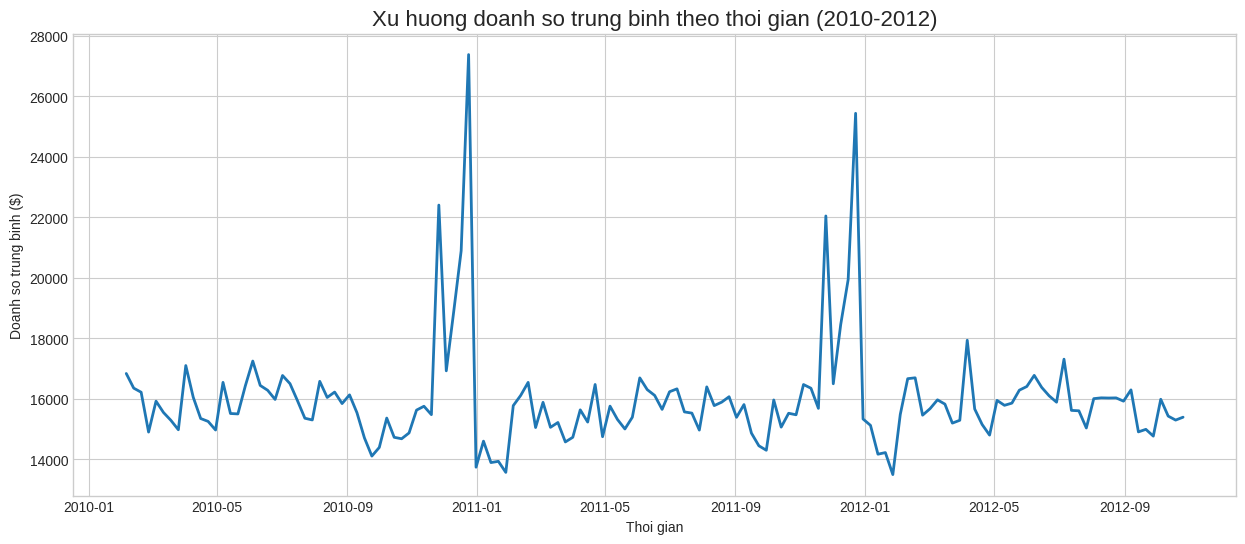

/tmp/ipython-input-1836017097.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsHoliday', y='Weekly_Sales', data=df, showfliers=False, palette='Set2')


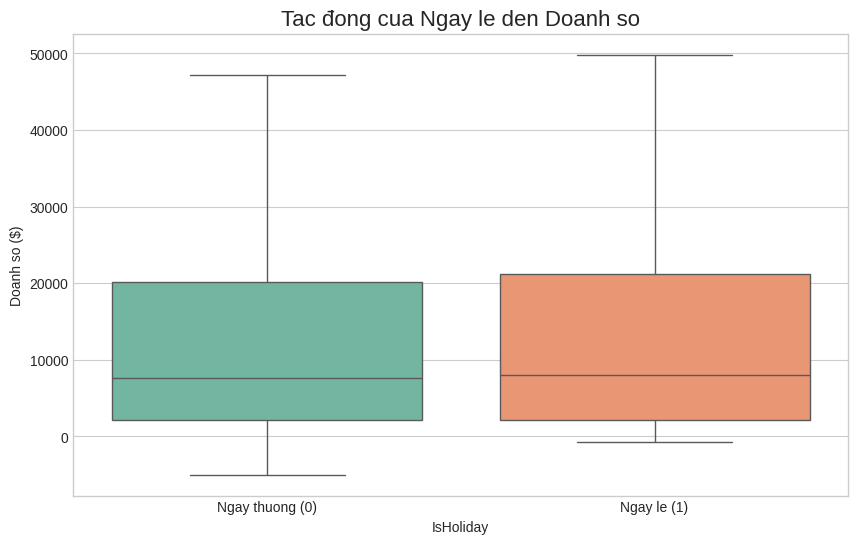

/tmp/ipython-input-1836017097.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Type', y='Weekly_Sales', data=df, showfliers=False, palette='viridis')


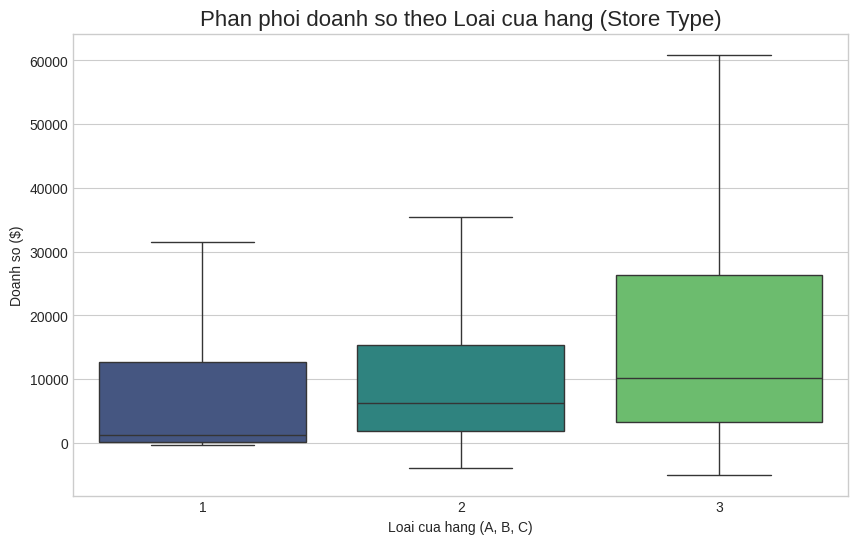

In [ ]:


import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt kích thước mặc định cho biểu đồ
plt.style.use('seaborn-v0_8-whitegrid')

#  Biểu đồ Xu hướng doanh số trung bình theo thời gian
sales_trend = df.groupby('Date')['Weekly_Sales'].mean()

plt.figure(figsize=(15, 6))
plt.plot(sales_trend.index, sales_trend.values, color='#1f77b4', linewidth=2)
plt.title('Xu huong doanh so trung binh theo thoi gian (2010-2012)', fontsize=16)
plt.ylabel('Doanh so trung binh ($)')
plt.xlabel('Thoi gian')
plt.show()

#  So sánh Doanh số Ngày thường vs Ngày lễ
plt.figure(figsize=(10, 6))
sns.boxplot(x='IsHoliday', y='Weekly_Sales', data=df, showfliers=False, palette='Set2')
plt.title('Tac đong cua Ngay le den Doanh so', fontsize=16)
plt.xticks([0, 1], ['Ngay thuong (0)', 'Ngay le (1)'])
plt.ylabel('Doanh so ($)')
plt.show()

# Phân phối doanh số theo Loại cửa hàng
plt.figure(figsize=(10, 6))
sns.boxplot(x='Type', y='Weekly_Sales', data=df, showfliers=False, palette='viridis')
plt.title('Phan phoi doanh so theo Loai cua hang (Store Type)', fontsize=16)
plt.xlabel('Loai cua hang (A, B, C)')
plt.ylabel('Doanh so ($)')
plt.show()

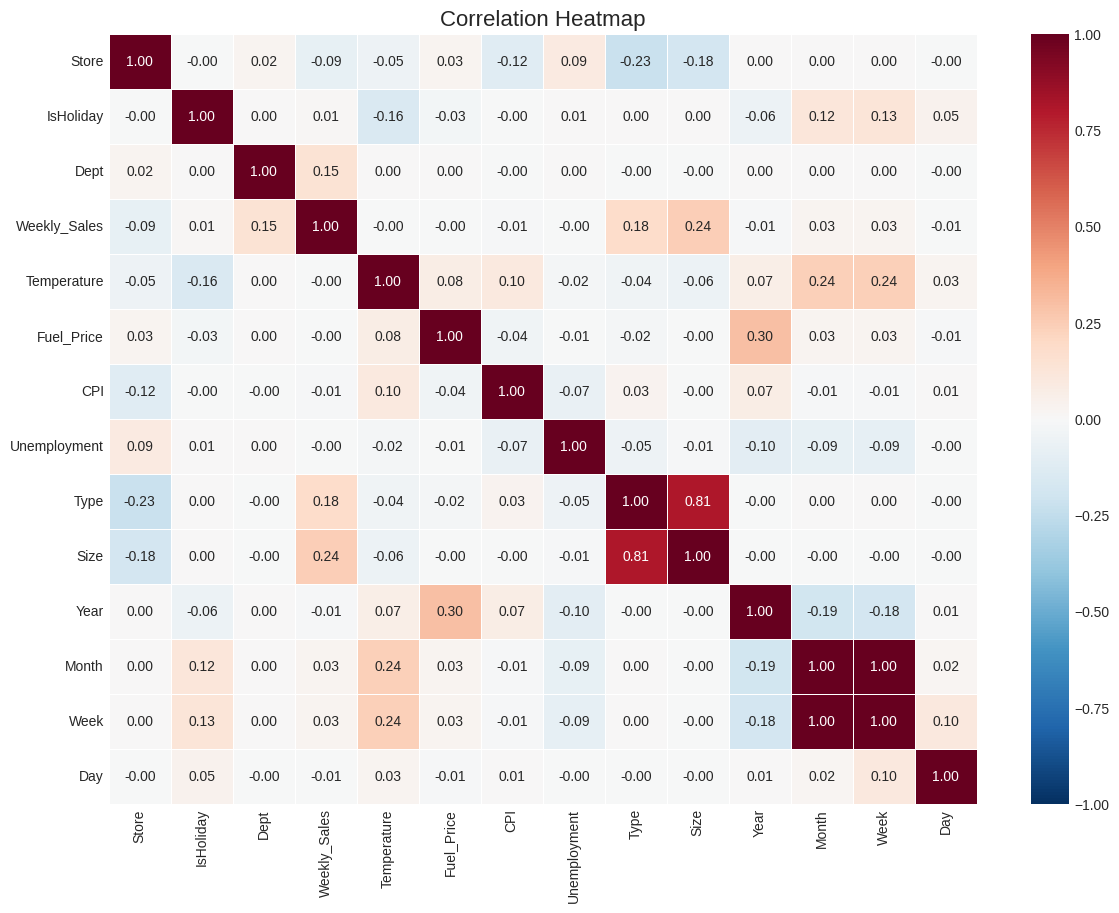

In [ ]:


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

# Tính toán ma trận tương quan
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Correlation Heatmap', fontsize=16)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Feature Engineering: Tạo các đặc trưng từ thời gian (Index)
df['Year'] = df.index.year
df['Month'] = df.index.month
df['Week'] = df.index.isocalendar().week
df['Day'] = df.index.day

#  Xác định biến Độc lập (X) và Phụ thuộc (y)
# Loại bỏ biến mục tiêu 'Weekly_Sales' khỏi X
X = df.drop(['Weekly_Sales'], axis=1)
y = df['Weekly_Sales']

#  Chia tập Train (Huấn luyện) và Test (Kiểm thử)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Kích thước tập huấn luyện:", X_train.shape)
print("Kích thước tập kiểm thử:", X_test.shape)

Kích thước tập huấn luyện: (337256, 13)
Kích thước tập kiểm thử: (84314, 13)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Tính MSE của mô hình Baseline (Dự báo bằng trung bình quá khứ)
# Đây là mẫu số cho công thức OOS R2
y_pred_baseline = np.full(shape=y_test.shape, fill_value=y_train.mean())
mse_baseline = mean_squared_error(y_test, y_pred_baseline)

def danh_gia_mo_hinh(model, X_test, y_test, model_name):
    # Dự báo
    y_pred = model.predict(X_test)

    # Tính các chỉ số
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Tính OOS R2: 1 - (MSE Model / MSE Baseline)
    oos_r2 = 1 - (mse / mse_baseline)

    print(f"--- KẾT QUẢ ĐÁNH GIÁ: {model_name} ---")
    print(f"MAE (Sai số tuyệt đối): {mae:,.2f}")
    print(f"RMSE (Sai số toàn phương): {rmse:,.2f}")
    print(f"R2 Score (Độ phù hợp): {r2:.4f}")
    print(f"OOS R2 (So với TB lịch sử): {oos_r2:.4f}")
    print("-" * 40)

    return [model_name, mae, rmse, r2, oos_r2]

# List để lưu kết quả so sánh sau này
ket_qua_so_sanh = []

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Khởi tạo mô hình
dt_model = DecisionTreeRegressor(random_state=42, max_depth=20)

# Huấn luyện

dt_model.fit(X_train, y_train)

# Đánh giá và lưu kết quả
res_dt = danh_gia_mo_hinh(dt_model, X_test, y_test, "Decision Tree")
ket_qua_so_sanh.append(res_dt)

--- KẾT QUẢ ĐÁNH GIÁ: Decision Tree ---
MAE (Sai số tuyệt đối): 1,756.52
RMSE (Sai số toàn phương): 4,358.56
R2 Score (Độ phù hợp): 0.9629
OOS R2 (So với TB lịch sử): 0.9629
----------------------------------------


Đang huấn luyện Random Forest (sẽ mất khoảng 1-2 phút)...
--- KẾT QUẢ ĐÁNH GIÁ: Random Forest ---
MAE (Sai số tuyệt đối): 1,385.57
RMSE (Sai số toàn phương): 3,273.09
R2 Score (Độ phù hợp): 0.9791
OOS R2 (So với TB lịch sử): 0.9791
----------------------------------------


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7871 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


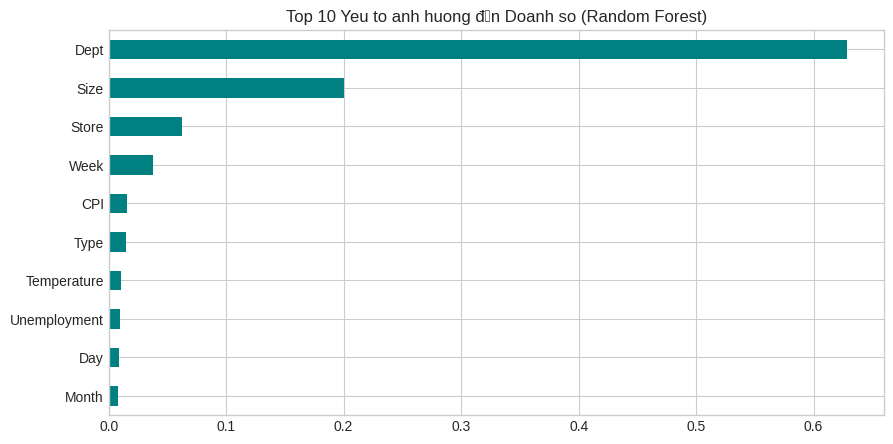

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Khởi tạo mô hình

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=20, n_jobs=-1)

# Huấn luyện
rf_model.fit(X_train, y_train)

# Đánh giá và lưu kết quả
res_rf = danh_gia_mo_hinh(rf_model, X_test, y_test, "Random Forest")
ket_qua_so_sanh.append(res_rf)

# Vẽ biểu đồ Feature Importance
plt.figure(figsize=(10, 5))
feat_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title("Top 10 Yeu to anh huong đến Doanh so (Random Forest)")
plt.show()

In [ ]:
from xgboost import XGBRegressor

# Khởi tạo mô hình
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

# Huấn luyện
print("Đang huấn luyện XGBoost...")
xgb_model.fit(X_train, y_train)

# Đánh giá và lưu kết quả
res_xgb = danh_gia_mo_hinh(xgb_model, X_test, y_test, "XGBoost")
ket_qua_so_sanh.append(res_xgb)

Đang huấn luyện XGBoost...
--- KẾT QUẢ ĐÁNH GIÁ: XGBoost ---
MAE (Sai số tuyệt đối): 3,863.30
RMSE (Sai số toàn phương): 6,888.05
R2 Score (Độ phù hợp): 0.9074
OOS R2 (So với TB lịch sử): 0.9074
----------------------------------------


BẢNG TỔNG HỢP KẾT QUẢ:
           Model          MAE         RMSE  R2 Score    OOS R2
0  Decision Tree  1756.522527  4358.558249  0.962934  0.962934
1  Random Forest  1385.571883  3273.091517  0.979097  0.979097
2        XGBoost  3863.303009  6888.047162  0.907427  0.907428
3  Random Forest  1385.571883  3273.091517  0.979097  0.979097
4  Random Forest  1385.571883  3273.091517  0.979097  0.979097
5  Decision Tree  1756.522527  4358.558249  0.962934  0.962934


/tmp/ipython-input-2776698705.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x='Model', y='R2 Score', data=df_results, palette='viridis')
/tmp/ipython-input-2776698705.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x='Model', y='OOS R2', data=df_results, palette='coolwarm')
/tmp/ipython-input-2776698705.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax3 = sns.barplot(x='Model', y='RMSE', data=df_results, palette='magma')


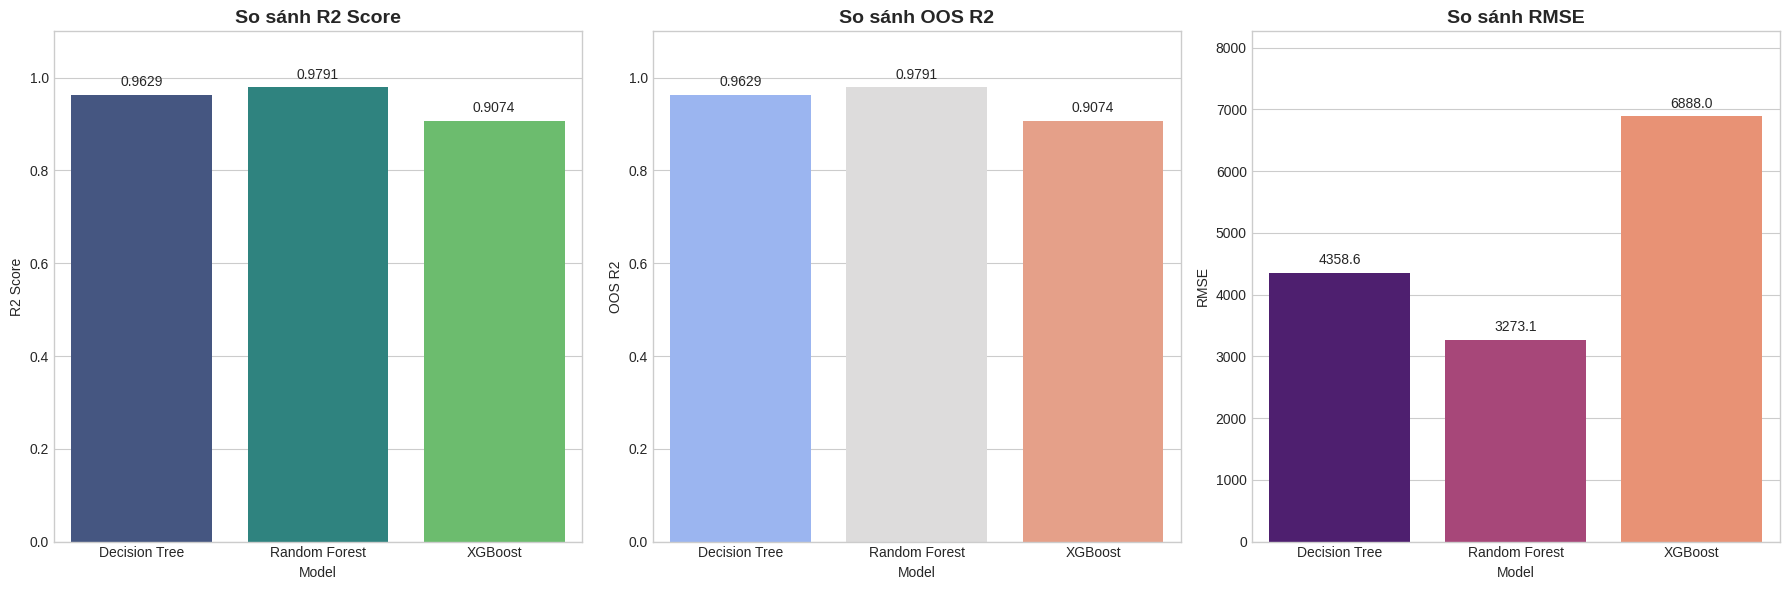


=> KL: Mo hinh tot nhat l Random Forest với OOS R2 = 0.9791


In [ ]:
# Tạo DataFrame so sánh
df_results = pd.DataFrame(ket_qua_so_sanh, columns=['Model', 'MAE', 'RMSE', 'R2 Score', 'OOS R2'])

print("BẢNG TỔNG HỢP KẾT QUẢ:")
print(df_results)

import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập kích thước tổng thể cho 3 biểu đồ
plt.figure(figsize=(18, 6))

#  Vẽ biểu đồ cho R2 Score (In-sample)
plt.subplot(1, 3, 1)
ax1 = sns.barplot(x='Model', y='R2 Score', data=df_results, palette='viridis')
plt.title('So sánh R2 Score', fontsize=14, fontweight='bold')
plt.ylim(0, 1.1)
for p in ax1.patches:
    ax1.annotate(format(p.get_height(), '.4f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center', xytext=(0, 9), textcoords='offset points')

#  Vẽ biểu đồ cho OOS R2 (Khả năng dự báo dữ liệu mới)
plt.subplot(1, 3, 2)
ax2 = sns.barplot(x='Model', y='OOS R2', data=df_results, palette='coolwarm')
plt.title('So sánh OOS R2', fontsize=14, fontweight='bold')
plt.ylim(0, 1.1)
for p in ax2.patches:
    ax2.annotate(format(p.get_height(), '.4f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center', xytext=(0, 9), textcoords='offset points')

# Vẽ biểu đồ cho RMSE (Càng thấp càng tốt)
plt.subplot(1, 3, 3)
ax3 = sns.barplot(x='Model', y='RMSE', data=df_results, palette='magma')
plt.title('So sánh RMSE', fontsize=14, fontweight='bold')

plt.ylim(0, df_results['RMSE'].max() * 1.2)
for p in ax3.patches:
    ax3.annotate(format(p.get_height(), '.1f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.tight_layout()
plt.show()

# Tìm ra mô hình tốt nhất
best_model = df_results.loc[df_results['OOS R2'].idxmax()]
print(f"\n=> KL: Mo hinh tot nhat l {best_model['Model']} với OOS R2 = {best_model['OOS R2']:.4f}")

In [ ]:
# --- BƯỚC CHUẨN BỊ DỮ LIỆU ĐỂ VẼ BIỂU ĐỒ ---

# 1. Chọn một Store và Dept cụ thể để visualize (Ví dụ: Store 1, Dept 1)
# Vì vẽ cả 400k dòng sẽ không nhìn thấy gì, ta cần "zoom" vào chi tiết.
subset_df = df[(df['Store'] == 1) & (df['Dept'] == 1)].copy()

# 2. Sắp xếp theo thời gian
subset_df = subset_df.sort_index()

# 3. Lấy 100 tuần cuối cùng để vẽ cho rõ nét
subset_df = subset_df.tail(100)

# 4. Tách X_subset để đưa vào dự báo
X_subset = subset_df.drop(['Weekly_Sales'], axis=1)
y_subset = subset_df['Weekly_Sales']

# 5. Thực hiện dự báo lại trên tập con này bằng 3 mô hình đã train
pred_dt = dt_model.predict(X_subset)
pred_rf = rf_model.predict(X_subset)
pred_xgb = xgb_model.predict(X_subset)

print("Đã chuẩn bị xong dữ liệu dự báo cho Store 1 - Dept 1.")

Đã chuẩn bị xong dữ liệu dự báo cho Store 1 - Dept 1.


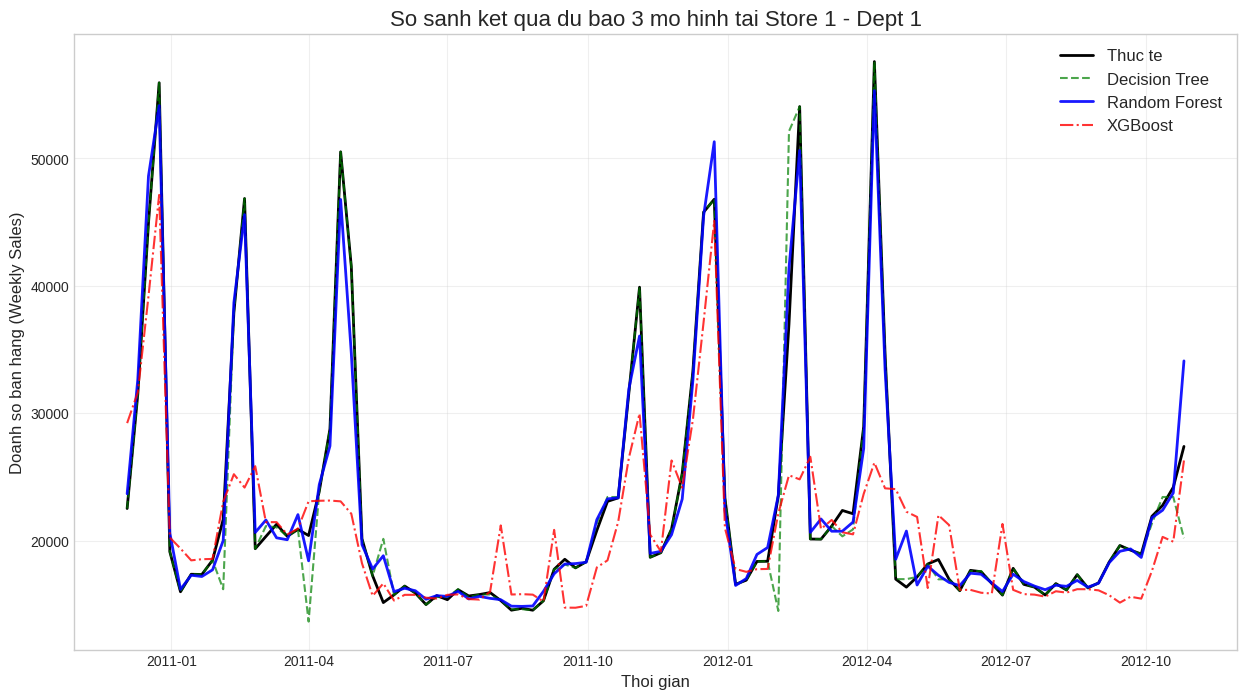

In [ ]:
# --- VẼ BIỂU ĐỒ SO SÁNH TRỰC QUAN ---
plt.figure(figsize=(15, 8))

# 1. Vẽ đường Thực tế (Actual)
plt.plot(subset_df.index, y_subset, label='Thuc te', color='black', linewidth=2, linestyle='-')

# 2. Vẽ đường dự báo của Decision Tree
plt.plot(subset_df.index, pred_dt, label='Decision Tree', color='green', linestyle='--', alpha=0.7)

# 3. Vẽ đường dự báo của Random Forest
plt.plot(subset_df.index, pred_rf, label='Random Forest', color='blue', linewidth=2, alpha=0.9)

# 4. Vẽ đường dự báo của XGBoost
plt.plot(subset_df.index, pred_xgb, label='XGBoost', color='red', linestyle='-.', alpha=0.8)

# Trang trí biểu đồ
plt.title('So sanh ket qua du bao 3 mo hinh tai Store 1 - Dept 1', fontsize=16)
plt.xlabel('Thoi gian', fontsize=12)
plt.ylabel('Doanh so ban hang (Weekly Sales)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Lưu ảnh để dán vào báo cáo
plt.savefig('so_sanh_forecast_3_models.png')
plt.show()

Dự báo doanh số cho 4 tuần tới (Store 1 - Dept 1):
--------------------------------------------------
Ngày            | Random Forest   | XGBoost        
--------------------------------------------------
2012-11-04      | 41,934.36        | 23,730.44
2012-11-11      | 23,702.43        | 19,781.83
2012-11-18      | 23,278.45        | 19,201.16
2012-11-25      | 23,767.91        | 27,810.04


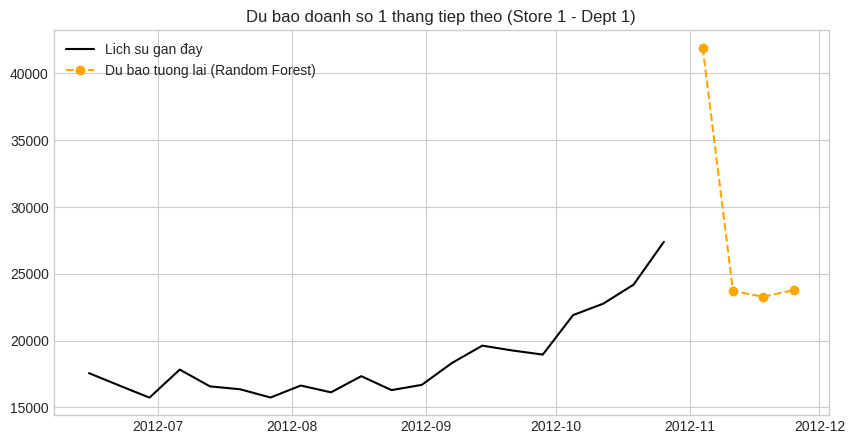

In [ ]:
# --- DỰ BÁO TƯƠNG LAI (FUTURE FORECAST) ---

#  Tạo dữ liệu giả lập cho 4 tuần tiếp theo (Dựa trên tuần cuối cùng của dữ liệu)
last_date = subset_df.index[-1]
future_dates = pd.date_range(start=last_date, periods=5, freq='W')[1:]

# Lấy dòng dữ liệu cuối cùng làm mẫu feature
last_row = X_subset.iloc[[-1]].copy()

# Tạo khung dữ liệu tương lai
future_predictions = []

print("Dự báo doanh số cho 4 tuần tới (Store 1 - Dept 1):")
print("-" * 50)
print(f"{'Ngày':<15} | {'Random Forest':<15} | {'XGBoost':<15}")
print("-" * 50)

for date in future_dates:
    # Cập nhật các feature thời gian cho dòng mẫu
    current_row = last_row.copy()
    current_row['Year'] = date.year
    current_row['Month'] = date.month
    current_row['Week'] = date.isocalendar().week
    current_row['Day'] = date.day

    # Dự báo
    pred_rf_future = rf_model.predict(current_row)[0]
    pred_xgb_future = xgb_model.predict(current_row)[0]

    print(f"{date.strftime('%Y-%m-%d'):<15} | {pred_rf_future:,.2f}        | {pred_xgb_future:,.2f}")

    future_predictions.append([date, pred_rf_future])

# Vẽ biểu đồ nối dài (Dữ liệu cũ + Dự báo tương lai của Random Forest)
dates_future = [x[0] for x in future_predictions]
sales_future = [x[1] for x in future_predictions]

plt.figure(figsize=(10, 5))
# Vẽ quá khứ
plt.plot(subset_df.index[-20:], y_subset[-20:], label='Lich su gan đay', color='black')
# Vẽ tương lai
plt.plot(dates_future, sales_future, label='Du bao tuong lai (Random Forest)', color='orange', marker='o', linestyle='--')

plt.title('Du bao doanh so 1 thang tiep theo (Store 1 - Dept 1)')
plt.legend()
plt.grid(True)
plt.show()